In [68]:
# Import packages
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np


In [69]:
data = pd.read_csv("../data/tsa-throughput-data-complete.csv")
data.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in data.columns]

In [70]:
data_proc = data.copy()
airport = 'ORD'

data_proc.drop(data_proc[data_proc['airport_code'] != airport].index, inplace=True)
data_proc.drop(data_proc[data_proc['total_passenger_throughput'] == 0].index, inplace=True)

data_proc['date'] = pd.to_datetime(data_proc['datetime']).dt.date
data_proc['month'] = pd.to_datetime(data_proc['datetime']).dt.month

#data_proc = data_proc[['datetime','total_passenger_throughput']]
#data_proc = data_proc.groupby(by=['date'],as_index=False).sum()
data_proc['datetime'] = pd.to_datetime(data_proc['datetime'])
data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1].reset_index() 

data_proc['week'] = pd.to_datetime(data_proc['datetime']).dt.strftime('%U').astype(int)

#data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1]


In [71]:
data_proc = data_proc.iloc[:-int(len(data_proc) * 0.25)]

In [72]:
import plotly.express as px

def plot_passenger_volumes(df: pd.DataFrame,
                           x: str,
                           y: str,
                           airport: str) -> None:
    """General function to plot the passenger data."""

    fig = px.line(df, x=x, y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), 
                      title_text='Airport Passengers: '+airport,
                      width=650, title_x=0.5, height=400)

    return fig.show()


data_proc["total_passenger_throughput_diff"] = data_proc["total_passenger_throughput"].diff()
plot_passenger_volumes(df=data_proc, x='datetime', y='total_passenger_throughput', airport=airport)

In [90]:
# Make the data stationary
data_proc['passengers_boxcox'], lam = boxcox(data_proc['total_passenger_throughput'])
data_proc["passengers_boxcox_diff"] = data_proc["passengers_boxcox"].diff()
data_proc.dropna(inplace=True)

data_proc['passengers_log'] = np.log(data_proc['total_passenger_throughput'])
data_proc['passengers_log_diff'] = data_proc['passengers_log'].diff()

data_proc['total_passenger_throughput_diff'] = data_proc['total_passenger_throughput'].diff()

# Plot the stationary passenger data
plot_passenger_volumes(df=data_proc,x='datetime', y='total_passenger_throughput_diff',airport=airport)

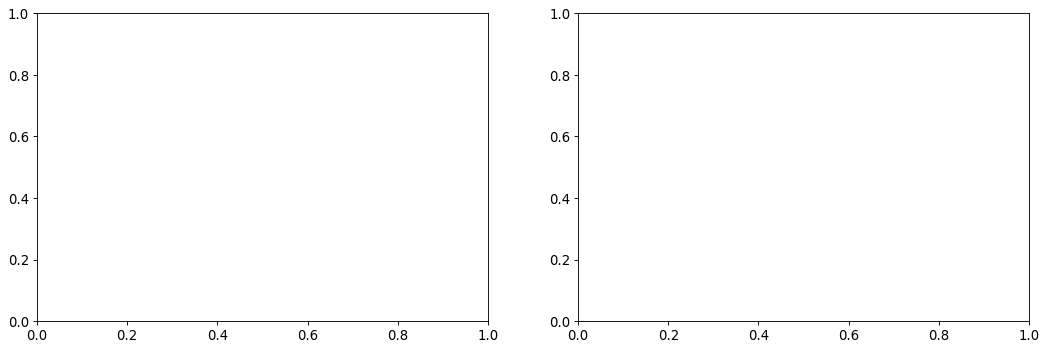

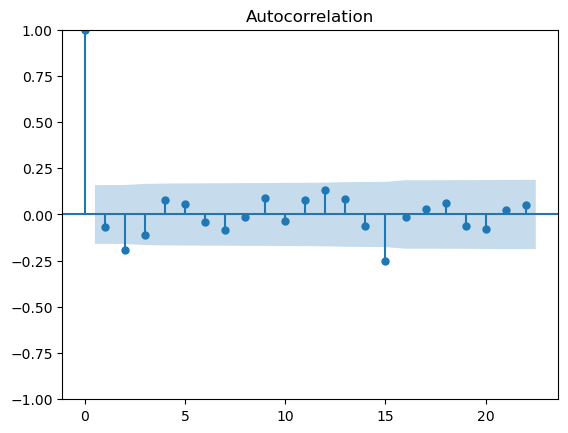

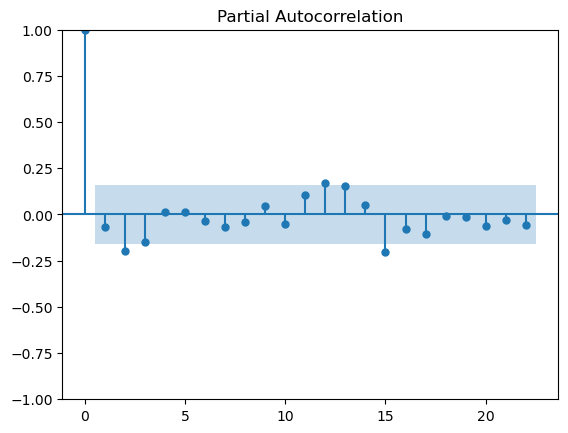

In [92]:
# Import packages
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot acf and pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(data_proc['passengers_boxcox_diff'])
plot_pacf(data_proc['passengers_boxcox_diff'])
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()

In [95]:
from pmdarima import auto_arima

model = auto_arima(data_proc['passengers_boxcox'], 
                   seasonal=True, 
                   stepwise=True, 
                   trace=True,
                   information_criterion='aic')
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8130.800, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8134.495, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8135.963, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8135.646, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8132.821, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8133.402, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8132.761, Time=0.02 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=8135.513, Time=0.06 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=8135.258, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8134.534, Time=0.02 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8134.485, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=8133.682, Time=0.03 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=8129.173, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0]             : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  152
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -4059.587
Date:                Wed, 11 Mar 2026   AIC                           8129.173
Time:                        10:42:36   BIC                           8144.260
Sample:                             0   HQIC                          8135.302
                                - 152                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0848      0.068     15.875      0.000       0.951       1.219
ar.L2         -0.8963      0.056    -15.920      0.000      -1.007      -0.786
ma.L1         -1.2108      0.059    -20.389      0.000      -1.327      -1.094
ma.L2          0.9607      0.051     18.870      0.000       0.861       1.060
sigma2      1.316e+22   4.67e-25   2.82e+46      0.000    1.32e+22    1.32e+22
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 8.69
Prob(Q):                              0.97   Prob(JB):                         0.01
Heteroskedasticity (H):               2.18   Skew:                             0.16
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.85e+62. Standard errors may be unstable.
"""

In [98]:
# Import packages
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.25)]
test = data_proc.iloc[-int(len(data_proc) * 0.25):]

# Build ARIMA model
#model = ARIMA(train['passengers_boxcox'], order=(1, 0, 0),
#              seasonal_order=(1, 1, 1, 52)).fit()
#ARIMA(0,1,0)(0,0,0)[0] 
#SARIMAX(p, d, q)x(P, D, Q, s)
model = ARIMA(train['passengers_boxcox'], order=(2,1,2),
              seasonal_order=(1, 1, 1, 52)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)

/Users/icaro/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

/Users/icaro/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [99]:
# Import packages
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passengers')

    return fig.show()

# Plot the forecasts
plot_forecasts(forecasts, 'SARIMA')

In [85]:
# Get fourier features
for order in range(1, 104):
    data_proc[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * data_proc['week'] / 52)
    data_proc[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * data_proc['week'] / 52)

# name of fourier features
fourier_features = [i for i in list(data_proc) if i.startswith('fourier')]

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.3)]
test = data_proc.iloc[-int(len(data_proc) * 0.3):]

# Build auto-ARIMA model with fourier features
model = pm.auto_arima(train['passengers_boxcox'],
                      X=train[fourier_features],
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True,
                      max_order=None,
                      information_criterion='aicc',
                      error_action="ignore")

# Get the forecasts and apply inverse box-cox transform
boxcox_forecasts = model.predict(n_periods=len(test), X=test[fourier_features])
forecasts = inv_boxcox(boxcox_forecasts, lam)

In [86]:
def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passenger Volume')

    return fig.show()


# Plot the forecasts
plot_forecasts(forecasts, 'Harmonic Regression')